# 3. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* Use the **logistic regression**.
* Three different **validation methodologies** used to tune hyperparameters, discussing the pros and cons of each.
* **Confusion matrices** for your models, and associated comments.
 * Evaluate your models using the following metrics and provide associated comments for each:
   - **ROC curve**
   - **precision-recall curve**
   - **F1 score**
   - **accuracy**
   - **recall**
   - **precision**
* A discussion of which **performance metric** is most relevant for the evaluation of your models.

Please remember to provide associated comments for each metric; it is not enough to just provide the metric values.

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option('display.max_columns', 1000)
data = pd.read_csv('secondary_data.csv')


# handling of missing values

data.isnull().sum()
missing_percent = data.isnull().mean() * 100
print(missing_percent)
all = data['class'].value_counts(normalize=True) * 100
print(all)

# rooted_stats = data[data['stem-root'].notna()]['class'].value_counts(normalize=True) * 100
# print(rooted_stats)

# spore_print_color = data[data['spore-print-color'].notna()]['class'].value_counts(normalize=True) * 100
# display(spore_print_color)

# veil_type = data[data['veil-type'].notna()]['class'].value_counts(normalize=True) * 100
# display(veil_type)

# veil_color = data[data['veil-color'].notna()]['class'].value_counts(normalize=True) * 100
# display(veil_color) 

# stem_surface = data[data['stem-surface'].notna()]['class'].value_counts(normalize=True) * 100
# display(stem_surface)


# analysis = data.groupby('stem-surface')['class'].value_counts(normalize=True).unstack() * 100
# print(analysis)

# analysis = data.groupby('veil-color')['class'].value_counts(normalize=True).unstack() * 100
# print(analysis)

data=data.drop(columns=["veil-type"])
data= data.fillna('missing')




class                    0.000000
cap-diameter             0.000000
cap-shape                0.000000
cap-surface             23.121387
cap-color                0.000000
does-bruise-or-bleed     0.000000
gill-attachment         16.184971
gill-spacing            41.040462
gill-color               0.000000
stem-height              0.000000
stem-width               0.000000
stem-root               84.393064
stem-surface            62.427746
stem-color               0.000000
veil-type               94.797688
veil-color              87.861272
has-ring                 0.000000
ring-type                4.046243
spore-print-color       89.595376
habitat                  0.000000
season                   0.000000
dtype: float64
class
p    55.491329
e    44.508671
Name: proportion, dtype: float64


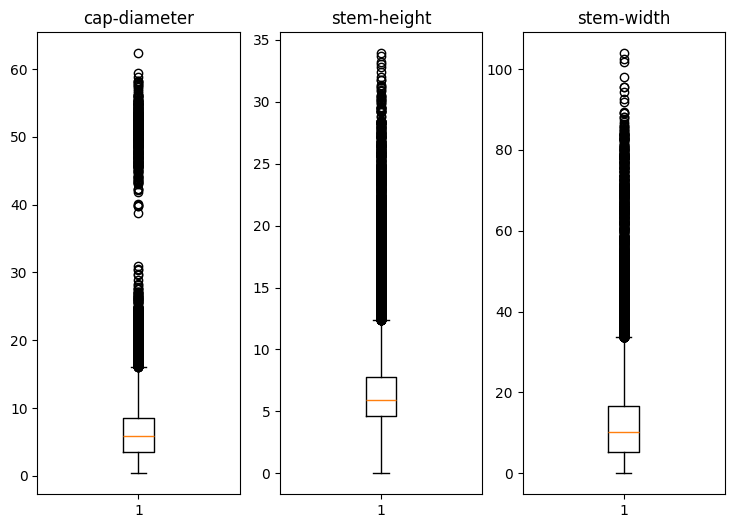

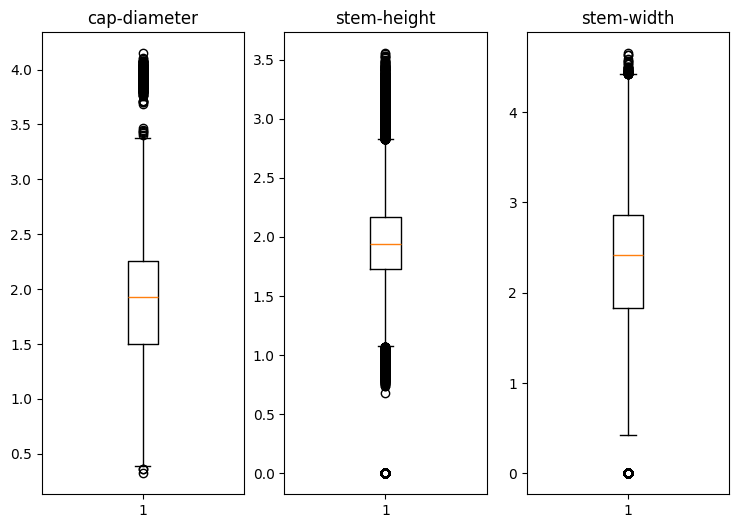

In [73]:
# outliers

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.boxplot(data["cap-diameter"])
plt.title("cap-diameter")

plt.subplot(1, 4, 2)
plt.boxplot(data["stem-height"])
plt.title("stem-height")

plt.subplot(1, 4, 3)
plt.boxplot(data["stem-width"])
plt.title("stem-width")

data["cap-diameter"] = data["cap-diameter"].apply(lambda x: np.log1p(x))
data["stem-height"] = data["stem-height"].apply(lambda x: np.log1p(x))
data["stem-width"] = data["stem-width"].apply(lambda x: np.log1p(x))

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.boxplot(data["cap-diameter"])
plt.title("cap-diameter")

plt.subplot(1, 4, 2)
plt.boxplot(data["stem-height"])
plt.title("stem-height")

plt.subplot(1, 4, 3)
plt.boxplot(data["stem-width"])
plt.title("stem-width")

# zeros = data[(data['stem-width']==0)]
# print(zeros)
# zeros2 = data[(data['stem-height']==0)]
# print(zeros2)

data['stem-height'] = data['stem-height'].replace(0, np.nan)
data['stem-width'] = data['stem-width'].replace(0, np.nan)

data['stem-height'] = data['stem-height'].fillna(data['stem-height'].median())
data['stem-width'] = data['stem-width'].fillna(data['stem-width'].median())

In [75]:
# one-hot encoding
from sklearn.preprocessing import LabelEncoder
data = pd.get_dummies(data, columns=["cap-shape", "cap-surface", "cap-color", "does-bruise-or-bleed", "gill-attachment", "gill-spacing", "gill-color", "stem-root", "stem-surface", "stem-color", "veil-color", "has-ring", "ring-type", "spore-print-color", "habitat", "season"], drop_first=True)
le = LabelEncoder()
data['class'] = le.fit_transform(data['class'])
data.head()


,class,cap-diameter,stem-height,stem-width,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_missing,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_t,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_missing,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_d,gill-spacing_f,gill-spacing_missing,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-root_c,stem-root_f,stem-root_missing,stem-root_r,stem-root_s,stem-surface_g,stem-surface_h,stem-surface_i,stem-surface_k,stem-surface_missing,stem-surface_s,stem-surface_t,stem-surface_y,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,veil-color_k,veil-color_missing,veil-color_n,veil-color_u,veil-color_w,veil-color_y,has-ring_t,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_missing,ring-type_p,ring-type_r,ring-type_z,spore-print-color_k,spore-print-color_missing,spore-print-color_n,spore-print-color_p,spore-print-color_r,spore-print-color_u,spore-print-color_w,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
0,1,2.788708,2.887590,2.895359,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,1,2.867899,2.943913,2.954389,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,1,2.712706,2.933857,2.930660,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,2.719320,2.819592,2.832036,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,F

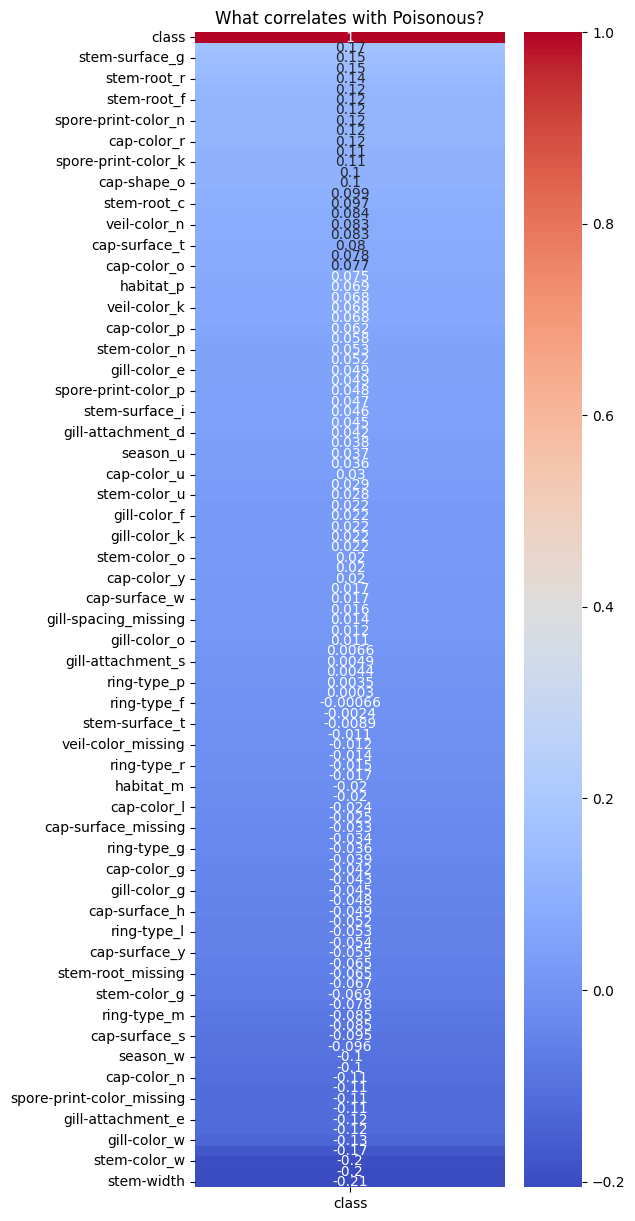

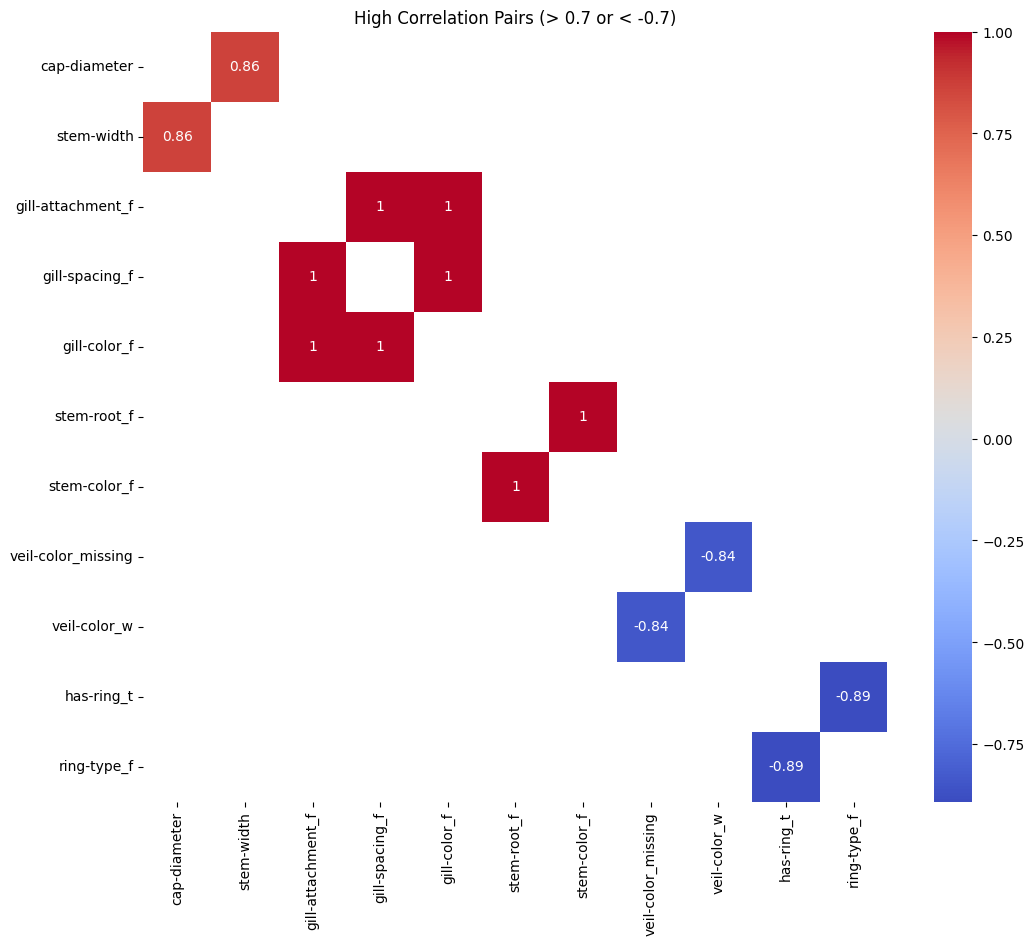

In [76]:
# correlation 

target_corr = data.corr()[['class']].sort_values(by='class', ascending=False)

plt.figure(figsize=(5, 15))
sns.heatmap(target_corr, annot=True, cmap="coolwarm")
plt.title("What correlates with Poisonous?")
plt.show()

corr = data.corr()

mask_self = np.eye(corr.shape[0]) == 0
corr_no_diag = corr.where(mask_self)

filtered_corr = corr_no_diag[((corr_no_diag >= 0.7) | (corr_no_diag <= -0.7))]

filtered_corr = filtered_corr.dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_corr, 
            annot=True, 
            cmap="coolwarm", 
           )

plt.title("High Correlation Pairs (> 0.7 or < -0.7)")
plt.show()

In [77]:
outliers = data[(data['has-ring_t'] == 1) & (data['ring-type_f'] == 1)]
print(f"Number of 'weird' mushrooms: {len(outliers)}")
print(outliers['class'].value_counts())

Number of 'weird' mushrooms: 2471
class
1    2118
0     353
Name: count, dtype: int64


In [78]:
print("Poisonous count for Missing Veil Color:")
print(data[data['veil-color_missing'] == 1]['class'].value_counts(normalize=True))

print("\nPoisonous count for White Veil Color:")
print(data[data['veil-color_w'] == 1]['class'].value_counts(normalize=True))

Poisonous count for Missing Veil Color:
class
1    0.552632
0    0.447368
Name: proportion, dtype: float64

Poisonous count for White Veil Color:
class
1    0.515893
0    0.484107
Name: proportion, dtype: float64


In [79]:
# correlation continuing

data = data.drop(columns=["gill-spacing_f", "gill-color_f", "stem-color_f", "veil-color_missing"])
data['diameter-and-width'] = data['cap-diameter'] * data['stem-width']
data = data.drop(columns=["cap-diameter", "stem-width"])
data.head()

,class,stem-height,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_missing,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_t,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_missing,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_d,gill-spacing_missing,gill-color_e,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-root_c,stem-root_f,stem-root_missing,stem-root_r,stem-root_s,stem-surface_g,stem-surface_h,stem-surface_i,stem-surface_k,stem-surface_missing,stem-surface_s,stem-surface_t,stem-surface_y,stem-color_e,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,veil-color_k,veil-color_n,veil-color_u,veil-color_w,veil-color_y,has-ring_t,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_missing,ring-type_p,ring-type_r,ring-type_z,spore-print-color_k,spore-print-color_missing,spore-print-color_n,spore-print-color_p,spore-print-color_r,spore-print-color_u,spore-print-color_w,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w,diameter-and-width
0,1,2.887590,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,8.074312
1,1,2.943913,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,8.472890
2,1,2.933857,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,7.950020
3,1,2.819592,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,7.701212
4,1,2.863914,Fals

In [80]:
#splitting the data
from sklearn.model_selection import train_test_split
X = data.drop(columns=["class"])
y = data["class"]
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)
X_train

,stem-height,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_missing,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_t,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_missing,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_d,gill-spacing_missing,gill-color_e,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-root_c,stem-root_f,stem-root_missing,stem-root_r,stem-root_s,stem-surface_g,stem-surface_h,stem-surface_i,stem-surface_k,stem-surface_missing,stem-surface_s,stem-surface_t,stem-surface_y,stem-color_e,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,veil-color_k,veil-color_n,veil-color_u,veil-color_w,veil-color_y,has-ring_t,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_missing,ring-type_p,ring-type_r,ring-type_z,spore-print-color_k,spore-print-color_missing,spore-print-color_n,spore-print-color_p,spore-print-color_r,spore-print-color_u,spore-print-color_w,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w,diameter-and-width
30120,2.117460,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,5.675097
47537,2.277267,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,1.792562
53873,1.818077,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,9.122762
37585,2.195000,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,1.422179
4729,

In [81]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[['diameter-and-width', 'stem-height']] = scaler.fit_transform(X_train[['diameter-and-width', 'stem-height']])
X_val[['diameter-and-width', 'stem-height']] = scaler.transform(X_val[['diameter-and-width', 'stem-height']])
X_test[['diameter-and-width', 'stem-height']] = scaler.transform(X_test[['diameter-and-width', 'stem-height']])